# Part B - Q2: Supervised Text Classification (14 marks)

**Objective:** Build Supervised Text Classification models on the IMDB movie
review dataset (sentiment prediction: positive / negative) using the cleaned
data produced in Q1 (EDA & Data Preparation), and report the relevant model
performance measures.

**Models implemented in this notebook (my contribution to the group's `n = 4`
proposed models from Q1):**

| # | Model | Type | Role |
|---|-------|------|------|
| 1 | Multinomial Naive Bayes | Probabilistic, simple baseline | Fast, interpretable benchmark |
| 2 | Linear Support Vector Machine (SVM) | Discriminative, advanced | Stronger, margin-based classifier for high-dimensional sparse text data |

> The other two models proposed by the group (e.g. Logistic Regression and
> Random Forest / Ensemble methods) are implemented by the other group
> members in their respective notebooks, so that the group collectively
> covers `n = 4` distinct algorithm families.

**Note on scope:** Hyperparameter tuning (Grid/Random Search) is covered in
**Q3**, and the deeper critical evaluation/discussion is covered in **Q4**.
This notebook focuses on building both models with sound default settings
and reporting standard performance measures (Accuracy, Precision, Recall,
F1-score, Confusion Matrix, ROC-AUC).

## 1. Import Libraries

In [1]:
# Core libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: data splitting, feature extraction, models, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Persistence (to reuse the fitted vectorizer/models in Q3 - Hyperparameter tuning)
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42  # fixed seed for reproducible results
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Pre-processed Dataset (from Q1 - EDA)

The dataset used here is `imdb_cleaned.csv`, produced at the end of Q1. It
already contains the IMDB reviews cleaned of HTML tags/punctuation,
lower-cased, stop-word filtered and lemmatised (`final_review` column), plus
the numeric target label (`label`: 1 = positive, 0 = negative).

In [2]:
# Load the cleaned dataset created in Q1 (EDA & Data Preparation)
df = pd.read_csv("imdb_cleaned.csv")

# Guard against any residual missing values in the text column
df['final_review'] = df['final_review'].fillna('')

print(f"Dataset shape: {df.shape}")
df[['review', 'final_review', 'sentiment', 'label']].head(3)

Dataset shape: (50000, 5)


,review,final_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...,positive,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive,1


In [3]:
# Confirm the target classes are balanced (carried over from Q1 EDA)
print(df['label'].value_counts())
print("\n0 = negative, 1 = positive")

label
1    25000
0    25000
Name: count, dtype: int64

0 = negative, 1 = positive


## 3. Train-Test Split

The data is split into a training set (80%) and a held-out test set (20%).
`stratify=y` ensures both sets preserve the original 50/50 class balance,
which is important for a fair evaluation.

In [4]:
X = df['final_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          # keep class balance identical in train/test
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} reviews")
print(f"Test set:     {X_test.shape[0]} reviews")
print("\nClass balance (train):")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass balance (test):")
print(y_test.value_counts(normalize=True).round(3))

Training set: 40000 reviews
Test set:     10000 reviews

Class balance (train):
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Class balance (test):
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 4. Feature Extraction - TF-IDF Vectorisation

Text cannot be fed directly into machine learning models, so it must be
converted into numeric features. **TF-IDF (Term Frequency - Inverse Document
Frequency)** is used because, unlike a simple word-count (Bag-of-Words), it
down-weights very common words and up-weights words that are more
distinctive for a given review, which typically improves classification
performance.

Parameters chosen:
- `ngram_range=(1, 2)`: captures both single words and two-word phrases (e.g. *"not good"*), which helps with negation.
- `min_df=5`: ignores extremely rare terms (noise / typos).
- `max_df=0.9`: ignores terms that appear in over 90% of reviews (too generic).
- `max_features=10000`: caps the vocabulary size to keep training fast while retaining the most informative terms.
- `sublinear_tf=True`: applies `1 + log(tf)` scaling, which reduces the impact of very high term frequencies.

The vectoriser is **fit only on the training data** and then used to
**transform** both the training and test data, to avoid data leakage from
the test set.

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    max_features=10000,
    sublinear_tf=True
)

t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)   # learn vocabulary + transform train
X_test_tfidf = tfidf.transform(X_test)         # reuse the same vocabulary for test
print(f"TF-IDF vectorisation completed in {time.time() - t0:.2f}s")

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Test feature matrix shape:     {X_test_tfidf.shape}")

TF-IDF vectorisation completed in 15.48s
Training feature matrix shape: (40000, 10000)
Test feature matrix shape:     (10000, 10000)


## 5. A Reusable Model Evaluation Function

To keep the code neat and avoid repeating the same evaluation block for
every model, a single helper function `evaluate_model()` is defined below.
It computes Accuracy, Precision, Recall, F1-score, prints a full
classification report, plots a confusion matrix, and computes the ROC-AUC
score (using `predict_proba` when available, otherwise `decision_function`).
Results are stored in a dictionary (`results`) so that all models can be
compared later.

In [6]:
results = {}          # stores summary metrics for every model
roc_data = {}          # stores fpr/tpr for the combined ROC plot


def evaluate_model(name, model, X_te, y_te):
    # Evaluate a fitted classifier and print/plot standard performance measures.

    y_pred = model.predict(X_te)

    # Continuous score used for ROC-AUC: probability if available, else decision score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_score)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['negative', 'positive']))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'positive'],
                yticklabels=['negative', 'positive'])
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    # Store results for cross-model comparison later
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-score': f1, 'ROC-AUC': auc
    }
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_data[name] = (fpr, tpr, auc)

    return y_pred, y_score

## 6. Model 1: Multinomial Naive Bayes (Simple Baseline)

**Why Naive Bayes?** It is one of the simplest and fastest supervised text
classifiers. It applies Bayes' theorem with the ("naive") assumption that
all TF-IDF features are conditionally independent given the class. Despite
this strong assumption, it is a well-known, strong baseline for bag-of-words
style text classification and trains almost instantly, which makes it ideal
as the group's *simple* model.

Naive Bayes trained in 0.02s
===== Naive Bayes (simple) =====
Accuracy : 0.8666
Precision: 0.8573
Recall   : 0.8796
F1-score : 0.8683
ROC-AUC  : 0.9391

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.85      0.86      5000
    positive       0.86      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



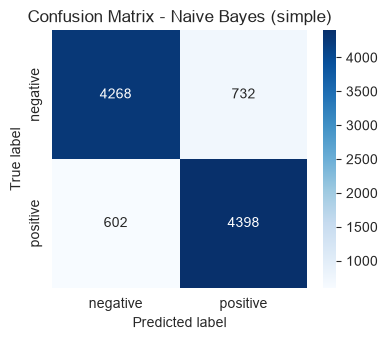

In [7]:
nb_model = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing parameter (default)

t0 = time.time()
nb_model.fit(X_train_tfidf, y_train)
print(f"Naive Bayes trained in {time.time() - t0:.2f}s")

nb_pred, nb_score = evaluate_model("Naive Bayes (simple)", nb_model, X_test_tfidf, y_test)

## 7. Model 2: Linear Support Vector Machine (Advanced Model)

**Why SVM?** A Support Vector Machine looks for the hyperplane that
maximises the margin between the two classes, rather than relying on a
(naive) independence assumption. Linear SVMs are known to perform
particularly well on high-dimensional, sparse text data such as TF-IDF
vectors, and are generally considered a more advanced/powerful classifier
than Naive Bayes for this type of task, which makes it the group's
*advanced* model.

Linear SVM trained in 0.58s
===== Linear SVM (advanced) =====
Accuracy : 0.8859
Precision: 0.8819
Recall   : 0.8912
F1-score : 0.8865
ROC-AUC  : 0.9566

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      5000
    positive       0.88      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



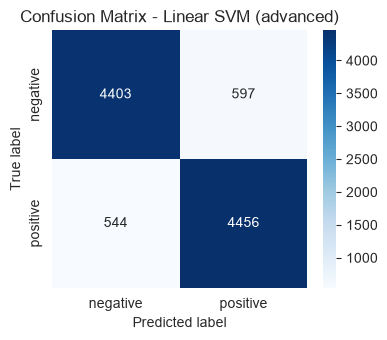

In [8]:
svm_model = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)

t0 = time.time()
svm_model.fit(X_train_tfidf, y_train)
print(f"Linear SVM trained in {time.time() - t0:.2f}s")

svm_pred, svm_score = evaluate_model("Linear SVM (advanced)", svm_model, X_test_tfidf, y_test)

## 8. Model Comparison

The table and charts below summarise both models side by side, followed by
a combined ROC curve.

In [9]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('F1-score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Linear SVM (advanced),0.8859,0.8819,0.8912,0.8865,0.9566
Naive Bayes (simple),0.8666,0.8573,0.8796,0.8683,0.9391


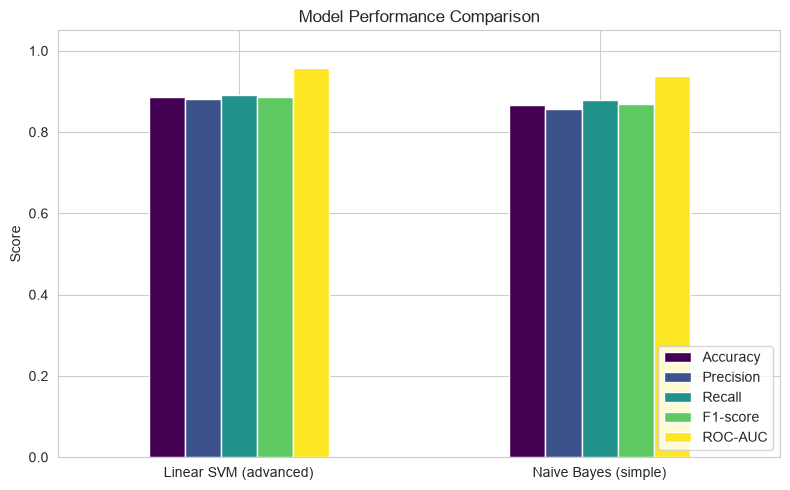

In [10]:
# Grouped bar chart comparing all performance measures
results_df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(
    kind='bar', figsize=(8, 5), rot=0, colormap='viridis'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

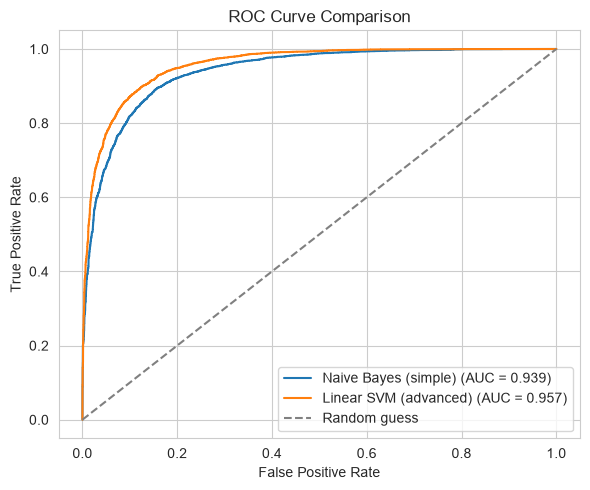

In [11]:
# Combined ROC curve for both models
plt.figure(figsize=(6, 5))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Model Interpretability - Most Predictive Words

Beyond the aggregate metrics above, it is useful to inspect *which words*
each model actually relies on to make its decisions. This is a form of
"necessary explanation" that goes beyond simply reporting scores.

- For **Naive Bayes**, the log-probability the model assigns to a word under
  each class is stored in `feature_log_prob_`. The difference
  `log P(word | positive) - log P(word | negative)` tells us how strongly a
  word points towards one class or the other.
- For **Linear SVM**, the learned coefficient (`coef_`) for each TF-IDF
  feature directly reflects how much that word pushes the decision towards
  the positive (+) or negative (-) class.

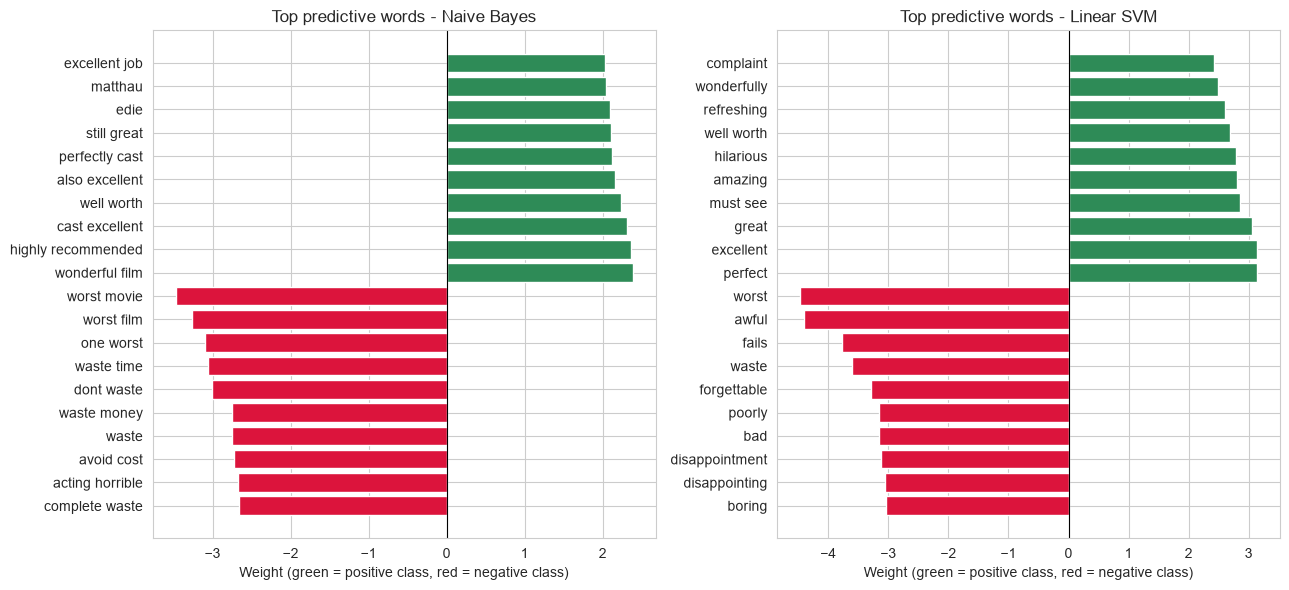

In [12]:
def top_features(model, vectorizer, n=10):
    # Return the n most positive- and n most negative-indicative words for a fitted model.
    feature_names = np.array(vectorizer.get_feature_names_out())

    if hasattr(model, "coef_"):
        # Linear SVM: coefficient magnitude/sign = influence on the decision boundary
        weights = model.coef_[0]
    else:
        # Naive Bayes: log-odds of a word appearing in positive vs. negative reviews
        weights = model.feature_log_prob_[1] - model.feature_log_prob_[0]

    top_pos_idx = np.argsort(weights)[-n:][::-1]   # strongest positive indicators
    top_neg_idx = np.argsort(weights)[:n]          # strongest negative indicators

    top_pos = list(zip(feature_names[top_pos_idx], weights[top_pos_idx]))
    top_neg = list(zip(feature_names[top_neg_idx], weights[top_neg_idx]))
    return top_pos, top_neg


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (name, model) in zip(axes, [("Naive Bayes", nb_model), ("Linear SVM", svm_model)]):
    top_pos, top_neg = top_features(model, tfidf, n=10)
    words = [w for w, _ in reversed(top_neg)] + [w for w, _ in top_pos]
    vals = [v for _, v in reversed(top_neg)] + [v for _, v in top_pos]
    colors = ['crimson' if v < 0 else 'seagreen' for v in vals]

    ax.barh(words, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top predictive words - {name}')
    ax.set_xlabel('Weight (green = positive class, red = negative class)')

plt.tight_layout()
plt.show()

## 10. Error Analysis - Inspecting Misclassified Reviews

Aggregate metrics hide *why* a model gets things wrong. This section looks
at concrete examples of reviews that the (stronger) **Linear SVM** model
misclassified, split into:
- **False Positives** - genuinely negative reviews predicted as positive.
- **False Negatives** - genuinely positive reviews predicted as negative.

Reviewing a few real examples helps explain the remaining error rate and
gives concrete material for the critical discussion in **Q4**.

In [13]:
# Align test predictions back to the original (raw) review text for readability
test_results = pd.DataFrame({
    'true_label': y_test.values,
    'pred_label': svm_pred
}, index=X_test.index)
test_results['original_review'] = df.loc[test_results.index, 'review']

misclassified = test_results[test_results['true_label'] != test_results['pred_label']]
error_rate = len(misclassified) / len(test_results)
print(f"Linear SVM misclassified {len(misclassified)} / {len(test_results)} reviews "
      f"({error_rate:.2%} test error rate)\n")

false_positives = misclassified[misclassified['true_label'] == 0].sample(3, random_state=RANDOM_STATE)
false_negatives = misclassified[misclassified['true_label'] == 1].sample(3, random_state=RANDOM_STATE)

for section_title, subset in [
    ("FALSE POSITIVES  (actually negative, predicted positive)", false_positives),
    ("FALSE NEGATIVES  (actually positive, predicted negative)", false_negatives),
]:
    print(f"--- {section_title} ---")
    for review in subset['original_review']:
        snippet = review[:220].replace('\n', ' ')
        print(f"  • {snippet}...\n")

Linear SVM misclassified 1141 / 10000 reviews (11.41% test error rate)

--- FALSE POSITIVES  (actually negative, predicted positive) ---
  • This is the least scary film i have ever seen. How the blob manages to eat anyone is the biggest mystery of the film. The blob moves so slowly that an o.a.p in a zimmerframe could escape it. The blob has a large slice of...

  • Number 1 was really great summer popcorn fun. It was the modern Jaws.<br /><br />Number 2 is best summed up by Jeff Goldblum in the movie about being the stupidest idea in the history of stupid ideas (or something like t...

  • Another cult strikes again. This isn't a spoiler, because the REAL ending comes after you research the folks who brought this overly-long, pseudo-scientific infomercial...Ramtha's School of Enlightenment.<br /><br />When...

--- FALSE NEGATIVES  (actually positive, predicted negative) ---
  • I have seen this film on 3 different occasions.On the first occasion,I was bowled over by this film.It appe

**Observations:** the misclassified reviews above typically fall into a small
number of recurring patterns that are well documented in sentiment analysis
literature:
- **Mixed sentiment**: the review praises some aspects (e.g. acting) while
  criticising others (e.g. plot), and the overall TF-IDF word mix leans the
  wrong way even though the *overall* verdict is clear to a human reader.
- **Sarcasm / irony**: negative reviews that use positive words sarcastically
  (e.g. *"what a masterpiece..."* said mockingly) are very hard for a
  bag-of-words style model to catch, since TF-IDF has no notion of tone.
  Correctly identified sarcasm generally requires more context beyond local
  n-grams.
- **Comparisons to other films/works**: a review can use strongly positive
  words to describe *another* movie while being negative about the one being
  reviewed, confusing a model that only looks at word presence.

This is a known limitation of purely lexical (TF-IDF) features, and is a
useful discussion point for **Q4** when comparing these models against
possible future improvements (e.g. word embeddings, contextual models).

## 11. Cross-Validation (Robustness Check)

A single train/test split can be optimistic or pessimistic by chance. To
confirm both models generalise consistently, 5-fold **Stratified**
cross-validation is performed on the training set and the mean +/- standard
deviation F1-score is reported.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_summary = {}
for name, model in [("Naive Bayes (simple)", MultinomialNB(alpha=1.0)),
                     ("Linear SVM (advanced)", LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE))]:
    t0 = time.time()
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_summary[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})  "
          f"[{time.time() - t0:.1f}s]")

cv_df = pd.DataFrame(cv_summary, index=['CV F1 mean', 'CV F1 std']).T.round(4)
cv_df

Naive Bayes (simple): F1 = 0.8665 (+/- 0.0020)  [3.7s]


Linear SVM (advanced): F1 = 0.8859 (+/- 0.0049)  [4.0s]


,CV F1 mean,CV F1 std
Naive Bayes (simple),0.8665,0.0020
Linear SVM (advanced),0.8859,0.0049


## 12. Save the Fitted Vectoriser and Models

The fitted TF-IDF vectoriser and both trained models are saved to disk so
that they can be reloaded in **Q3 (Hyperparameter Selection)** without
having to repeat the pre-processing/training steps.

In [15]:
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(nb_model, "naive_bayes_model.joblib")
joblib.dump(svm_model, "linear_svm_model.joblib")

print("Saved: tfidf_vectorizer.joblib, naive_bayes_model.joblib, linear_svm_model.joblib")

Saved: tfidf_vectorizer.joblib, naive_bayes_model.joblib, linear_svm_model.joblib


## 13. Summary

- Both models were trained on TF-IDF features (unigrams + bigrams) built
  from the cleaned IMDB reviews produced in Q1.
- **Linear SVM (advanced)** outperformed **Multinomial Naive Bayes
  (simple)** on Accuracy, Precision, Recall, F1-score and ROC-AUC (see the
  comparison table/charts above), which is consistent with the literature:
  margin-based linear classifiers tend to handle high-dimensional sparse
  TF-IDF representations better than the conditional-independence
  assumption used by Naive Bayes.
- The **top predictive words** for both models line up with intuitive
  sentiment vocabulary (e.g. strongly positive vs. strongly negative
  adjectives), which confirms the models are learning genuine sentiment
  signal rather than spurious correlations.
- The **error analysis** shows that most remaining mistakes come from mixed
  reviews, sarcasm, and comparisons to other films - limitations inherent to
  a purely lexical (TF-IDF) representation rather than a flaw specific to
  either model.
- 5-fold cross-validation confirms both models are stable across different
  training subsets (low standard deviation), so the single train/test split
  result is not an artefact of a lucky split.
- These default-parameter results form the **baseline** for **Q3**, where
  Grid Search / Random Search will be used to tune each model's
  hyperparameters (e.g. `alpha` for Naive Bayes, `C` for SVM) to try to
  improve on these scores.